In [1]:
import numpy as np 
from sklearn.datasets import load_iris 
from sklearn.linear_model import Perceptron

In [2]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa

In [3]:
per_clf = Perceptron(random_state=42) 
per_clf.fit(X,y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [4]:
X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)

In [5]:
def calc_xor(inputs: np.matrix, weights: np.matrix, bias: float) -> np.matrix:
    linear_output = np.vdot(weights.T, inputs).item() + bias
    if linear_output < 0:
        return 0
    else:
        return 1

In [6]:
inputs = [np.matrix([0,0]), np.matrix([1,1]), np.matrix([0,1]), np.matrix([1,0])]
for matrix in inputs:
    layer_1_weights = np.matrix([1,1])
    layer_2_weights = np.matrix([-1,1])
    output_1, output_2 = calc_xor(matrix, layer_1_weights, -3/2), calc_xor(matrix, layer_1_weights, -1/2)
    final_input = np.matrix([output_1, output_2])
    print(calc_xor(final_input, layer_2_weights, -1/2))

0
0
0
0


In [7]:
print(np.vdot(np.matrix([0,0]).T, np.matrix([1,1])).item())

0


In [8]:
x_range = np.arange(-4,5)
sigmoid = [1 / (1 + np.exp(-x)) for x in x_range]
heaviside = np.piecewise(x_range, [x_range < 0, x_range >= 0], [0,1])
hyp_tang = np.tanh(x_range)
relu = [np.fmax(0,x) for x in x_range]
functions = {"Sigmoid": sigmoid, "Heaveside": heaviside, "Tanh": hyp_tang, "ReLU": relu}

C:\Users\Logan\AppData\Local\Temp\ipykernel_61540\278713337.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(x_range, heaviside, 'o-', marker="", label='Heaveside')
C:\Users\Logan\AppData\Local\Temp\ipykernel_61540\278713337.py:7: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "p-." (-> marker='p'). The keyword argument will take precedence.
  plt.plot(x_range, relu, 'p-.',marker="", label='ReLU')


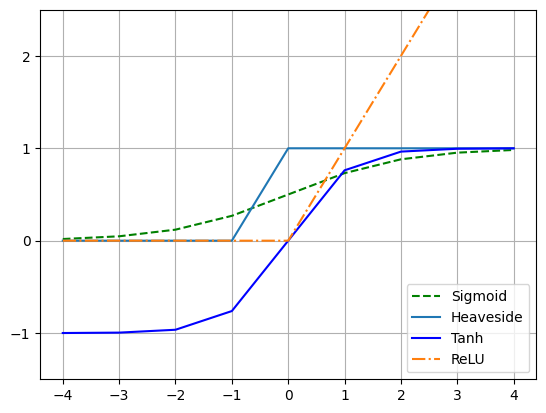

In [9]:
import matplotlib.pyplot as plt
from scipy import interpolate

plt.plot(x_range,sigmoid,'g--', marker="", label='Sigmoid')
plt.plot(x_range, heaviside, 'o-', marker="", label='Heaveside')
plt.plot(x_range, hyp_tang, 'b-', marker="", label='Tanh')
plt.plot(x_range, relu, 'p-.',marker="", label='ReLU')
plt.ylim([-1.5,2.5])
plt.yticks(np.arange(-1,3))
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [10]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [11]:
housing = fetch_california_housing()

In [12]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42)

In [14]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50], random_state=42) 
pipeline = make_pipeline(StandardScaler(), mlp_reg)

In [15]:
pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"[50, 50, ...]"
,activation,'relu'
,solver,'adam'


In [16]:
y_pred = pipeline.predict(X_val)

In [17]:
rmse = root_mean_squared_error(y_pred, y_val)

In [18]:
rmse

0.505332665796845

In [19]:
import tensorflow as tf

In [20]:
tf.keras.backend.clear_session()

In [21]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5_000], y_train_full[:-5_000]
X_val, y_val = X_train_full[-5_000:], y_train_full[-5_000:]

In [22]:
X_train.shape

(55000, 28, 28)

In [23]:
X_train.dtype

dtype('uint8')

In [24]:
X_train, X_val, X_test = X_train / 255., X_val / 255., X_test / 255.

In [25]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [26]:
class_names[y_train[0]]

'Ankle boot'

In [27]:
tf.random.set_seed(42) 
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28,28])) 
model.add(tf.keras.layers.Flatten()) 
model.add(tf.keras.layers.Dense(300, activation="relu")) 
model.add(tf.keras.layers.Dense(100, activation="relu")) 
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]

In [31]:
hidden1 = model.layers[1]

In [32]:
hidden1.name

'dense_3'

In [33]:
model.get_layer('dense_3') is hidden1

True

In [34]:
weights, biases = hidden1.get_weights()

In [35]:
weights

array([[ 0.04085099, -0.00714672,  0.06848097, ..., -0.01124983,
         0.04019694, -0.02618799],
       [ 0.01611722,  0.03428282, -0.06754699, ...,  0.06269221,
        -0.01908017,  0.03070267],
       [-0.04002105,  0.073272  , -0.03232337, ..., -0.03004693,
         0.03955422, -0.02175071],
       ...,
       [ 0.00078137,  0.00863574, -0.06899033, ..., -0.01374398,
         0.03136496, -0.06665604],
       [-0.02947185,  0.0073696 ,  0.04183058, ..., -0.00071143,
         0.02214055,  0.05045928],
       [ 0.0243004 , -0.0611307 ,  0.04030885, ...,  0.05408908,
         0.06595354, -0.03142057]], shape=(784, 300), dtype=float32)

In [36]:
weights.shape

(784, 300)

In [37]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [38]:
biases.shape

(300,)

In [39]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [40]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7654 - loss: 0.7055 - val_accuracy: 0.8220 - val_loss: 0.5103
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8304 - loss: 0.4876 - val_accuracy: 0.8370 - val_loss: 0.4573
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8457 - loss: 0.4424 - val_accuracy: 0.8462 - val_loss: 0.4314
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8549 - loss: 0.4147 - val_accuracy: 0.8522 - val_loss: 0.4147
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8618 - loss: 0.3940 - val_accuracy: 0.8546 - val_loss: 0.4043
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8672 - loss: 0.3773 - val_accuracy: 0.8564 - val_loss: 0.3948
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8713 - loss: 0.3634 - val_accuracy: 0.8588 - val_loss: 0.3874
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8755 - loss: 0.351

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

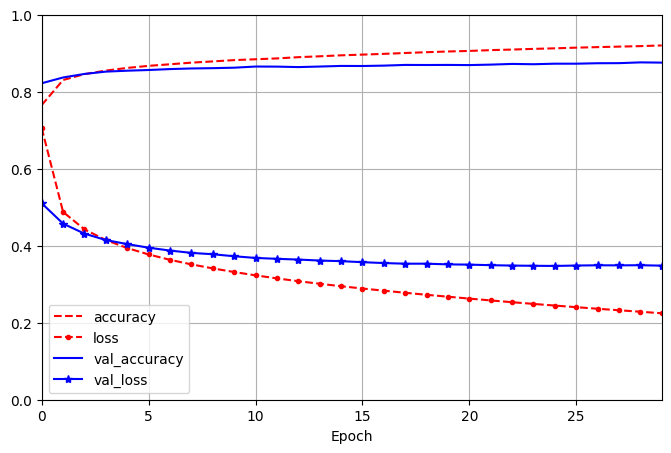

In [42]:
pd.DataFrame(history.history).plot(
    figsize=(8,5), xlim=[0,29], ylim=[0,1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [43]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8747 - loss: 0.3636


[0.3635694682598114, 0.8747000098228455]

In [44]:
X_new = X_test[:3] 
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.22, 0.  , 0.02, 0.  , 0.77],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [45]:
import numpy as np

In [46]:
y_pred = y_proba.argmax(axis=1)

In [47]:
y_pred

array([9, 2, 1])

In [48]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [49]:
y_new = y_test[:3] 
y_new

array([9, 2, 1], dtype=uint8)

In [50]:
tf.random.set_seed(42) 
norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:]) 
model = tf.keras.Sequential([ 
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"), 
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
    ])

C:\Users\Logan\Desktop\Python\Hands_On_Machine_Learning\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [52]:
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

In [53]:
norm_layer.adapt(X_train)

In [54]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_val, y_val))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - RootMeanSquaredError: 2.9305 - loss: 8.5877 - val_RootMeanSquaredError: 2.9009 - val_loss: 8.4154
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - RootMeanSquaredError: 2.8810 - loss: 8.2999 - val_RootMeanSquaredError: 2.8997 - val_loss: 8.4080
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - RootMeanSquaredError: 2.8780 - loss: 8.2831 - val_RootMeanSquaredError: 2.9004 - val_loss: 8.4120
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - RootMeanSquaredError: 2.8766 - loss: 8.2746 - val_RootMeanSquaredError: 2.8988 - val_loss: 8.4032
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - RootMeanSquaredError: 2.8756 - loss: 8.2692 - val_RootMeanSquaredError: 2.8972 - val_loss: 8.3939
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - RootMeanSquaredError: 2.8747 - loss: 8.2638 - val_RootMeanSquaredError: 2.8949 - val_loss: 8.3806
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - RootMeanSquaredEr

In [55]:
mse, rmse = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 2.8732 - loss: 8.2552


In [56]:
X_new = X_test[:3]
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [57]:
normalization_layer = tf.keras.layers.Normalization() 
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

In [58]:
input_ = tf.keras.layers.Input(shape=X_train.shape[1:]) 
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

In [59]:
model = tf.keras.Model(inputs=[input_], outputs = [output])

In [60]:
tf.keras.backend.clear_session()

In [61]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42)

In [62]:
X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_val_wide, X_val_deep = X_val[:, :5], X_val[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

In [63]:
input_wide = tf.keras.layers.Input(shape=[5]) # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6]) # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [64]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3) 
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

In [65]:
print(tf.__version__)

2.21.0


In [66]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20,
    validation_data=((X_val_wide, X_val_deep), y_val))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.1393 - loss: 1.2980 - val_RootMeanSquaredError: 1.1102 - val_loss: 1.2325
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6818 - loss: 0.4648 - val_RootMeanSquaredError: 0.6363 - val_loss: 0.4048
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6469 - loss: 0.4185 - val_RootMeanSquaredError: 0.6376 - val_loss: 0.4065
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6317 - loss: 0.3990 - val_RootMeanSquaredError: 0.6025 - val_loss: 0.3630
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6217 - loss: 0.3865 - val_RootMeanSquaredError: 0.5954 - val_loss: 0.3545
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6145 - loss: 0.3776 - val_RootMeanSquaredError: 0.5888 - val_loss: 0.3467
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6085 - los

In [67]:
input_wide = tf.keras.layers.Input(shape=[5]) # features 0 to 4
input_deep = tf.keras.layers.Input(shape=[6]) # features 2 to 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])

In [73]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9,0.1), optimizer=optimizer,
              metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

In [74]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20,
                    validation_data=((X_val_wide, X_val_deep), (y_val, y_val)))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_5_RootMeanSquaredError: 1.2135 - dense_5_loss: 1.4721 - dense_6_RootMeanSquaredError: 1.3933 - dense_6_loss: 1.9406 - loss: 1.5195 - val_dense_5_RootMeanSquaredError: 0.8042 - val_dense_5_loss: 0.6467 - val_dense_6_RootMeanSquaredError: 2.2951 - val_dense_6_loss: 5.2650 - val_loss: 1.1089
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_5_RootMeanSquaredError: 0.7445 - dense_5_loss: 0.5542 - dense_6_RootMeanSquaredError: 0.8811 - dense_6_loss: 0.7763 - loss: 0.5765 - val_dense_5_RootMeanSquaredError: 0.7027 - val_dense_5_loss: 0.4937 - val_dense_6_RootMeanSquaredError: 1.5808 - val_dense_6_loss: 2.4980 - val_loss: 0.6943
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_5_RootMeanSquaredError: 0.6767 - dense_5_loss: 0.4579 - dense_6_RootMeanSquaredError: 0.7832 - dense_6_loss: 0.6134 - loss: 0.4735 - val_dense_5_RootMeanSquaredError: 1.0393 - val_dense_5_loss: 1.0796 - val_dense_6_RootMeanSquaredError: 0.8

In [75]:
eval_results = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss, main_rmse, aux_rmse = eval_results

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_5_RootMeanSquaredError: 0.5739 - dense_5_loss: 0.3290 - dense_6_RootMeanSquaredError: 0.6269 - dense_6_loss: 0.3929 - loss: 0.3357


In [76]:
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


In [77]:
y_pred_tuple = model.predict((X_new_wide, X_new_deep)) 
y_pred = dict(zip(model.output_names, y_pred_tuple))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [78]:
y_pred

{'dense_5': array([[0.5307034],
        [1.1572665],
        [3.4832094]], dtype=float32),
 'dense_6': array([[0.6044203],
        [0.9807931],
        [3.2064836]], dtype=float32)}

In [120]:
import keras
@keras.saving.register_keras_serializable()
class WideAndDeepModel(tf.keras.Model): 
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs) # needed to support naming the model
        self.norm_layer_wide = tf.keras.layers.Normalization() 
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation) 
        self.main_output = tf.keras.layers.Dense(1) 
        self.aux_output = tf.keras.layers.Dense(1)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep) 
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1) 
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

In [121]:
model = WideAndDeepModel(30, activation="relu", name="my_cool_model")

In [122]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9,0.1), optimizer=optimizer,
              metrics=["RootMeanSquaredError", "RootMeanSquaredError"])
model.norm_layer_wide.adapt(X_train_wide)
model.norm_layer_deep.adapt(X_train_deep)
model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20, 
          validation_data=((X_val_wide, X_val_deep), (y_val, y_val)))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.4363 - RootMeanSquaredError_1: 1.5261 - loss: 2.0895 - mse_loss: 2.3284 - val_RootMeanSquaredError: 1.8572 - val_RootMeanSquaredError_1: 2.9903 - val_loss: 3.9986 - val_mse_loss: 8.9377
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.8360 - RootMeanSquaredError_1: 0.9338 - loss: 0.7162 - mse_loss: 0.8719 - val_RootMeanSquaredError: 1.1680 - val_RootMeanSquaredError_1: 2.2898 - val_loss: 1.7521 - val_mse_loss: 5.2409
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.7377 - RootMeanSquaredError_1: 0.7856 - loss: 0.5515 - mse_loss: 0.6172 - val_RootMeanSquaredError: 0.7888 - val_RootMeanSquaredError_1: 1.4601 - val_loss: 0.7732 - val_mse_loss: 2.1310
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6812 - RootMeanSquaredError_1: 0.7414 - loss: 0.4726 - mse_loss: 0.5497 - val_RootMeanSquaredError: 0.6661 - val_RootMeanSquaredEr

In [123]:
model.save("my_keras_model.keras")

In [125]:
model = tf.keras.models.load_model("my_keras_model.keras")
y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [127]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_checkpionts.weights.h5", 
                                                   save_weights_only=True)

In [128]:
history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20, 
                    validation_data=((X_val_wide, X_val_deep), (y_val, y_val)), 
                   callbacks=[checkpoint_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 0.5757 - RootMeanSquaredError_1: 0.6293 - loss: 0.3379 - mse_loss: 0.3961 - val_RootMeanSquaredError: 0.7111 - val_RootMeanSquaredError_1: 0.8054 - val_loss: 0.5199 - val_mse_loss: 0.6485
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5747 - RootMeanSquaredError_1: 0.6282 - loss: 0.3368 - mse_loss: 0.3947 - val_RootMeanSquaredError: 0.7737 - val_RootMeanSquaredError_1: 0.7306 - val_loss: 0.5921 - val_mse_loss: 0.5337
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5737 - RootMeanSquaredError_1: 0.6256 - loss: 0.3354 - mse_loss: 0.3914 - val_RootMeanSquaredError: 0.8510 - val_RootMeanSquaredError_1: 0.9222 - val_loss: 0.7369 - val_mse_loss: 0.8502
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5744 - RootMeanSquaredError_1: 0.6261 - loss: 0.3361 - mse_loss: 0.3921 - val_RootMeanSquaredError: 0.9936 - val_RootMeanSquaredEr

In [129]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

In [130]:
history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20, 
                    validation_data=((X_val_wide, X_val_deep), (y_val, y_val)), 
                   callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5606 - RootMeanSquaredError_1: 0.6027 - loss: 0.3191 - mse_loss: 0.3633 - val_RootMeanSquaredError: 0.7693 - val_RootMeanSquaredError_1: 0.8862 - val_loss: 0.6112 - val_mse_loss: 0.7850
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5526 - RootMeanSquaredError_1: 0.5969 - loss: 0.3104 - mse_loss: 0.3564 - val_RootMeanSquaredError: 0.5409 - val_RootMeanSquaredError_1: 0.5917 - val_loss: 0.2984 - val_mse_loss: 0.3501
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5506 - RootMeanSquaredError_1: 0.5943 - loss: 0.3082 - mse_loss: 0.3533 - val_RootMeanSquaredError: 0.6376 - val_RootMeanSquaredError_1: 0.7118 - val_loss: 0.4165 - val_mse_loss: 0.5065
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5500 - RootMeanSquaredError_1: 0.5935 - loss: 0.3075 - mse_loss: 0.3523 - val_RootMeanSquaredError: 0.5427 - val_RootMeanSquaredEr

In [132]:
class PrivntValTrainingRatioCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        ratio = logs["val_loss"] / logs["loss"]
        print(f"Epoch={epoch}, val/train={ratio:.2f}")

In [135]:
from pathlib import Path 
from time import strftime

In [144]:
def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")
run_logdir = get_run_logdir()

In [146]:
tensoroard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                               profile_batch=(100,200))
history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20, 
                    validation_data=((X_val_wide, X_val_deep), (y_val, y_val)), 
                    callbacks=[tensoroard_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.5379 - RootMeanSquaredError_1: 0.5790 - loss: 0.2940 - mse_loss: 0.3353 - val_RootMeanSquaredError: 0.9702 - val_RootMeanSquaredError_1: 0.8680 - val_loss: 0.9226 - val_mse_loss: 0.7531
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5365 - RootMeanSquaredError_1: 0.5764 - loss: 0.2922 - mse_loss: 0.3323 - val_RootMeanSquaredError: 0.5925 - val_RootMeanSquaredError_1: 0.6224 - val_loss: 0.3547 - val_mse_loss: 0.3873
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5364 - RootMeanSquaredError_1: 0.5761 - loss: 0.2921 - mse_loss: 0.3320 - val_RootMeanSquaredError: 0.7126 - val_RootMeanSquaredError_1: 0.7457 - val_loss: 0.5127 - val_mse_loss: 0.5560
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5342 - RootMeanSquaredError_1: 0.5751 - loss: 0.2899 - mse_loss: 0.3308 - val_RootMeanSquaredError: 0.5390 - val_RootMeanSquaredEr

In [156]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [166]:
import os
# Temporarily remove the Jupyter-specific matplotlib backend
os.environ.pop('MPLBACKEND', None)

'module://matplotlib_inline.backend_inline'

In [167]:
%matplotlib inline
%tensorboard --logdir=./my_logs

In [169]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)

        data = (np.random.randn(100) + 2) * step / 100 # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)

        images = np.random.randn(2, 32, 32, 3) * step / 1000 # gets brighter
        tf.summary.image("my_image", images, step=step)

        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)

        sine_wave = tf.math.sin(tf.range(12_000) / 48_000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1,-1,1])
        tf.summary.audio("my_audio", audio, sample_rate=48_000, step=step)